In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from qtpy import binding_specified
from scrapy.utils.defer import defer_result

sns.set_theme(style="whitegrid",font_scale = 1.2)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

由于数据集中无消费金额,只用R(最近一次消费)和F(消费频率)两个维度对用户进行分组

In [ ]:
df = pd.read_parquet('user_behavior_cleaned_dataset.parquet')

In [ ]:
df_F = df.groupby('user_id').size()
print(df_F)

In [ ]:
df_date_deadline = df.groupby('user_id')['date'].max()
all_deadline = pd.to_datetime('2017-12-03')
df_R = (all_deadline - df_date_deadline).dt.days
print(df_R)

In [ ]:
df_result = df_F.to_frame('F').join(df_R.to_frame('R')).reset_index().rename(columns={'index':'user_id'})
print(df_result)

In [24]:
bins_r = [-1,0,2,4,6,100]
labels_r = [5,4,3,2,1]
df_result['r_score'] = pd.cut(df_result['R'], bins=bins_r, labels=labels_r)
df_result['F_pct'] = df_result['F'].rank(pct=True,method='first')
bins_f = [0,0.2,0.4,0.6,0.8,1]
labels_f = [1,2,3,4,5]
df_result['f_score'] = pd.cut(df_result['F_pct'], bins=bins_f, labels=labels_f)
df_result = df_result.dropna(subset=['r_score'])
df_result['all_score'] = df_result['f_score'].astype(int) + df_result['r_score'].astype(int)
print(df_result)


       user_id    F  R r_score     F_pct f_score  all_score
0            1   55  0       5  0.360518       2          7
1           13   11  0       5  0.022741       1          6
2          100   98  0       5  0.606450       4          9
3          115  241  0       5  0.920114       5         10
4          117  170  0       5  0.821898       5         10
...        ...  ... ..     ...       ...     ...        ...
10197  1017990   59  0       5  0.394236       2          7
10198  1017994   35  0       5  0.215840       2          7
10199  1017997   95  0       5  0.597726       3          8
10200  1018000  185  0       5  0.849833       5         10
10201  1018011   42  0       5  0.269947       2          7

[10200 rows x 7 columns]


In [23]:
# 检查 r_score 和 f_score 的缺失值数量
print(df_result[['r_score', 'f_score']].isna().sum())

# 查看是否有任何一行的 r_score 或 f_score 为 NaN
print(df_result[df_result['r_score'].isna() | df_result['f_score'].isna()])

r_score    2
f_score    0
dtype: int64
      user_id    F    R r_score     F_pct f_score
2456   109117  170   -1     NaN  0.822192       5
6682   130701  116 -268     NaN  0.685846       4


In [26]:
# 先将 r_score 和 f_score 转为整数
df_result['r_score'] = df_result['r_score'].astype(int)
df_result['f_score'] = df_result['f_score'].astype(int)

# 然后再计算中位数
r_median = df_result['r_score'].median()
f_median = df_result['f_score'].median()
print(f"R 中位数: {r_median}, F 中位数: {f_median}")

R 中位数: 5.0, F 中位数: 3.0


定义用户分层

In [27]:
# 定义分界线
r_median = 5
f_median = 3

# 定义分层函数
def rfm_segment(row):
    if row['r_score'] >= r_median and row['f_score'] >= f_median:
        return '高价值用户'
    elif row['r_score'] < r_median and row['f_score'] >= f_median:
        return '重点挽留用户'
    elif row['r_score'] >= r_median and row['f_score'] < f_median:
        return '潜力/新用户'
    else:
        return '流失用户'

# 应用函数，生成标签列
df_result['segment'] = df_result.apply(rfm_segment, axis=1)

# 查看分层结果
print(df_result['segment'].value_counts())

segment
高价值用户     6066
潜力/新用户    3948
流失用户       132
重点挽留用户      54
Name: count, dtype: int64


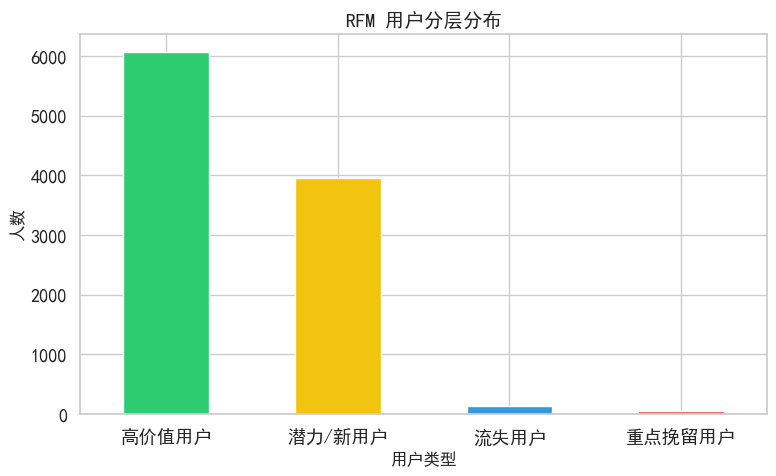

In [28]:
# 按分层统计人数
segment_counts = df_result['segment'].value_counts()

# 绘制柱状图
plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar', color=['#2ecc71', '#f1c40f', '#3498db', '#e74c3c'])
plt.title('RFM 用户分层分布', fontsize=14)
plt.xlabel('用户类型', fontsize=12)
plt.ylabel('人数', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('rfm_segment_distribution.png', dpi=300)
plt.show()